In [145]:
# Source - https://stackoverflow.com/a/62767559

#!gdown 1FBSL51xFotdcWycsUaxvNYcnuallVjOg
!gdown 1rC9lB-M-zb3Y_eGMlfXSmnl_MfF8QQHk

Downloading...
From (original): https://drive.google.com/uc?id=1rC9lB-M-zb3Y_eGMlfXSmnl_MfF8QQHk
From (redirected): https://drive.google.com/uc?id=1rC9lB-M-zb3Y_eGMlfXSmnl_MfF8QQHk&confirm=t&uuid=292b29b3-1d53-4aaa-8f79-c394a15203b6
To: /content/matched_df.csv.gz
100% 202M/202M [00:01<00:00, 153MB/s]


In [149]:
import pandas as pd
import seaborn as sns
import tarfile
import numpy as np
import matplotlib.pyplot as plt

In [151]:
df = pd.read_csv('matched_df.csv.gz', compression='gzip')
df.shape

(3256352, 6)

In [90]:
#df = pd.read_csv('/content/matched_df.csv')
#df.shape

(1342236, 6)

In [152]:
df.head(5)

,login,link,description,score,vacancy_skills,git_skills
0,0niel,https://hh.ru/vacancy/131058426?query=python+%...,Рассматриваются вакансии только с фотографиями...,0.473003,"['Python', 'GitHub', 'Gitlab', 'FastAPI', 'NoS...","['Dart', 'TypeScript', 'Java', 'C++', 'C']"
1,0xPh0enix,https://hh.ru/vacancy/131058426?query=python+%...,Рассматриваются вакансии только с фотографиями...,0.391739,"['Python', 'GitHub', 'Gitlab', 'FastAPI', 'NoS...","['C#', 'C++']"
2,0xcds4r,https://hh.ru/vacancy/131058426?query=python+%...,Рассматриваются вакансии только с фотографиями...,0.412302,"['Python', 'GitHub', 'Gitlab', 'FastAPI', 'NoS...","['C++', 'C']"
3,1111alexandrr,https://hh.ru/vacancy/131058426?query=python+%...,Рассматриваются вакансии только с фотографиями...,0.383303,"['Python', 'GitHub', 'Gitlab', 'FastAPI', 'NoS...","['Go', 'Rust']"
4,13xforever,https://hh.ru/vacancy/131058426?query=python+%...,Рассматриваются вакансии только с фотографиями...,0.483172,"['Python', 'GitHub', 'Gitlab', 'FastAPI', 'NoS...","['C#', 'C', 'C++', 'Python']"


In [153]:
np.percentile(df['score'], 95) # Смотрим какая у нас граница для "хороших" скоров - +-0.5

np.float64(0.4830672453682741)

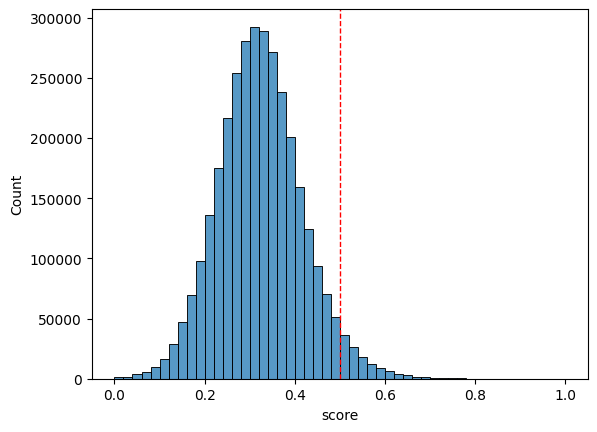

In [154]:
sns.histplot(data=df, x="score", bins=50)
plt.axvline(0.5, color="red", linestyle='--', linewidth=1, label=None)

Мы посмотрели на данные и видим, что у нас в основном оценки до 0.5 (т.к. 0.48 это вообще 95-ный перцентиль), это возьмем за границу. Сравним с тем, как это идет относительно вакансий

In [155]:
df_fg = df.groupby(["link", 'description'])["score"].mean().reset_index()
df_fg

,link,description,score
0,https://hh.ru/vacancy/104886191?query=%D0%BF%D...,"АО ""ЭВРИКА"" — российская аккредитованная IT-ко...",0.370479
1,https://hh.ru/vacancy/106110133?query=%D0%BF%D...,Приглашаем системного программиста С в команду...,0.319671
2,https://hh.ru/vacancy/108609738?query=android+...,Описание Платформенные команды Т‑Банка обеспеч...,0.359041
3,https://hh.ru/vacancy/108747455?query=javascri...,Требования: Разработкой фронтенд-интерфейсов с...,0.518288
4,https://hh.ru/vacancy/112405984?query=%D0%BF%D...,В команду нашей IT-практики открыта вакансия П...,0.363549
...,...,...,...
3353,https://hh.ru/vacancy/90599147?query=python+%D...,Компания UserGate - аккредитованный российский...,0.354524
3354,https://hh.ru/vacancy/92354865?query=php+devel...,Perfect Panel — успешная международная компани...,0.312647
3355,https://hh.ru/vacancy/94851638?query=%D0%BF%D1...,Требования: высшее техническое образование; хо...,0.377825
3356,https://hh.ru/vacancy/96836951?query=%D0%BF%D1...,"АО ""ЭВРИКА"" — российская аккредитованная IT-ко...",0.358645


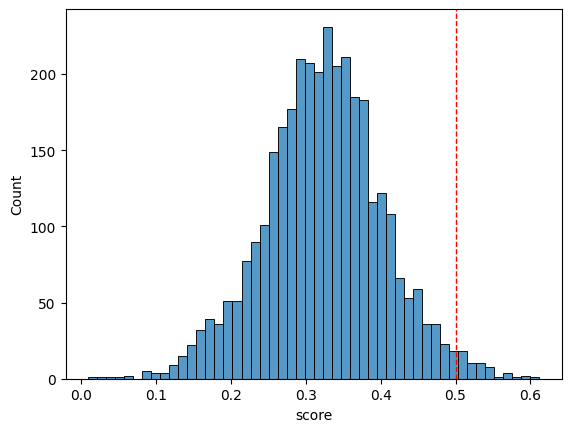

In [156]:
sns.histplot(data=df_fg, x="score", bins=50)
plt.axvline(0.5, color="red", linestyle='--', linewidth=1, label=None)

Картина чуть смещена влево - слабые отзывы перетягивают на себя меньшее количество хороших отзывов, снижая среднее

In [157]:
# https://stackoverflow.com/questions/1894269/how-to-convert-string-representation-of-list-to-a-list
import ast

df["vacancy_skills_count"] = df["vacancy_skills"].apply(lambda x: len(ast.literal_eval(x)))

In [158]:
df_g = df[df["score"]>0.3][["link", 'description', "score", "vacancy_skills_count"]].groupby(["link", 'description']).agg(
    sc_mean=pd.NamedAgg(column="score", aggfunc="mean"),
    sc_count=pd.NamedAgg(column="score", aggfunc="count"), #https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.api.typing.DataFrameGroupBy.agg.html
    vs_mean=pd.NamedAgg(column="vacancy_skills_count", aggfunc="mean")
).reset_index()
df_g

,link,description,sc_mean,sc_count,vs_mean
0,https://hh.ru/vacancy/104886191?query=%D0%BF%D...,"АО ""ЭВРИКА"" — российская аккредитованная IT-ко...",0.375391,920,7.0
1,https://hh.ru/vacancy/106110133?query=%D0%BF%D...,Приглашаем системного программиста С в команду...,0.347407,646,4.0
2,https://hh.ru/vacancy/108609738?query=android+...,Описание Платформенные команды Т‑Банка обеспеч...,0.366218,887,4.0
3,https://hh.ru/vacancy/108747455?query=javascri...,Требования: Разработкой фронтенд-интерфейсов с...,0.518761,966,6.0
4,https://hh.ru/vacancy/112405984?query=%D0%BF%D...,В команду нашей IT-практики открыта вакансия П...,0.372844,877,1.0
...,...,...,...,...,...
3142,https://hh.ru/vacancy/89743558?query=%D0%BF%D1...,Право на отсрочку от призыва на военную службу...,0.319801,320,5.0
3143,https://hh.ru/vacancy/90599147?query=python+%D...,Компания UserGate - аккредитованный российский...,0.370798,804,13.0
3144,https://hh.ru/vacancy/92354865?query=php+devel...,Perfect Panel — успешная международная компани...,0.348082,561,12.0
3145,https://hh.ru/vacancy/94851638?query=%D0%BF%D1...,Требования: высшее техническое образование; хо...,0.397061,816,8.0


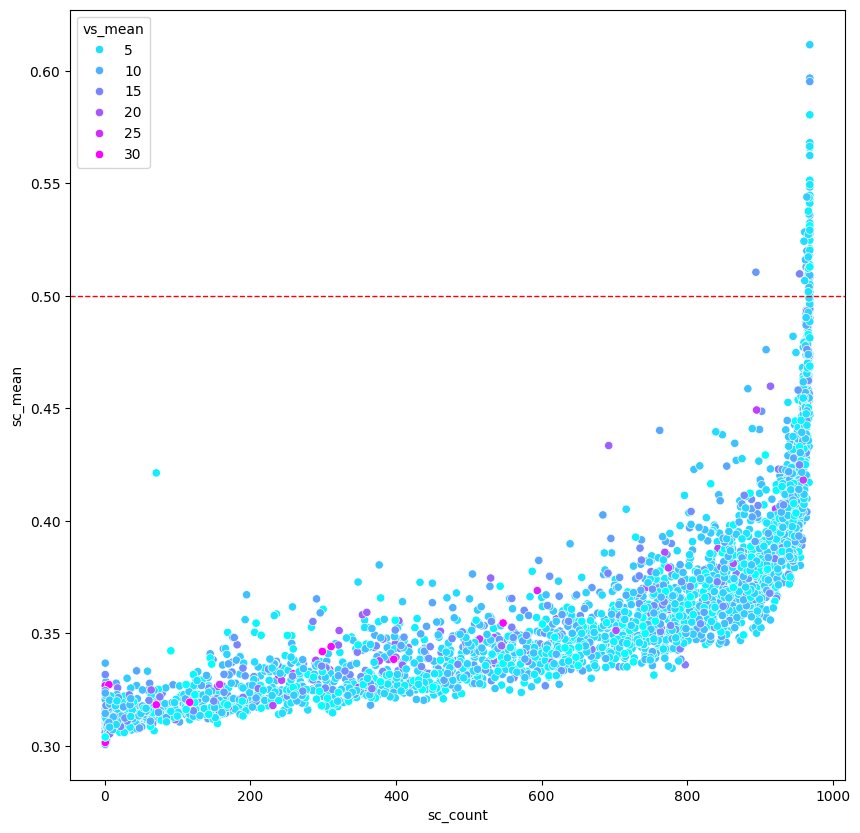

In [159]:
plt.figure(figsize=(10,10))
sns.scatterplot(df_g, x="sc_count", y="sc_mean", palette="cool", hue = "vs_mean")
plt.axhline(0.5, color="red", linestyle='--', linewidth=1, label=None)

Вот здесь уже стоит посмотреть - по сути мы видим определенный пласт вакансий, которые более-менее подошли все пользователям, что говорит о по сути "общности" описания. В остальном мы видим, что среднее очень низкое - из-за большого количества слабых совпадений

<Axes: ylabel='Frequency'>

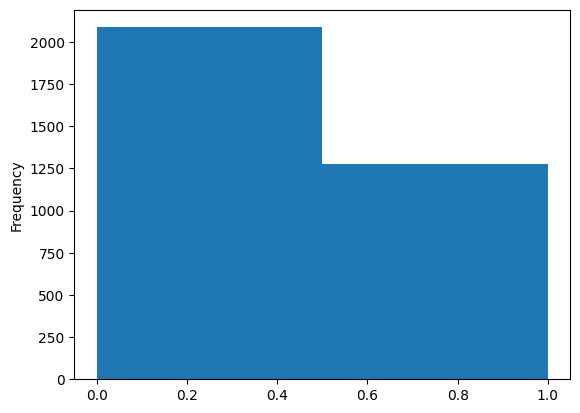

In [160]:
# Мы выделили трешхолд 0.5
df["score_filt"] = (df["score"]>0.5).astype(int)
df_c_vac = df[["link", "score_filt"]].groupby(["link"]).agg(
    count_users=pd.NamedAgg(column="score_filt", aggfunc="sum")
).reset_index()
(df_c_vac["count_users"]>0).astype(int).plot.hist(bins=2)

Видим, что у нас 2/3 вакансий остались без отклика - это, к сожалению, так и должно быть - многие из них описаны очень сомнительно и/или и не предполагают наличие репозитория у кандидата

<Axes: xlabel='count_users', ylabel='Count'>

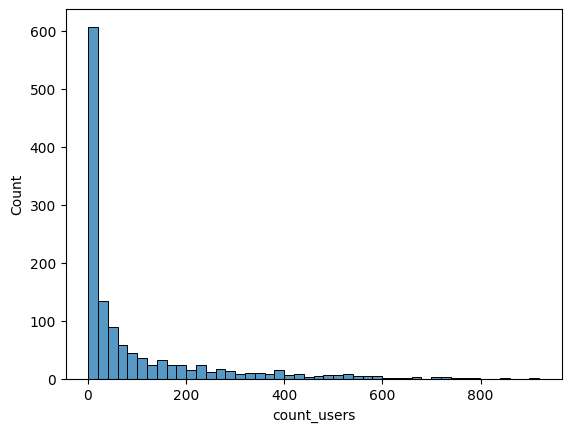

In [161]:
sns.histplot(data=df_c_vac[df_c_vac["count_users"]>0], x="count_users")

Здесь уже видим количество людей на вакансию - в целом не считая графика выше (где у нас как раз-таки нули видны), у нас большая часть вакансий достаточно точная и туда в первую очередь подходят именно малое коол-во работников

In [166]:
df["git_skills_count"] = df["git_skills"].apply(lambda x: len(ast.literal_eval(x)))

In [171]:
df_logins = df[df["score"] > 0.3].groupby(["login"]).agg(
    sc_mean=pd.NamedAgg(column="score", aggfunc="mean"),
    sc_count=pd.NamedAgg(column="score", aggfunc="count"),
    vs_mean=pd.NamedAgg(column="vacancy_skills_count", aggfunc="mean")
).reset_index()

<Axes: xlabel='sc_count', ylabel='sc_mean'>

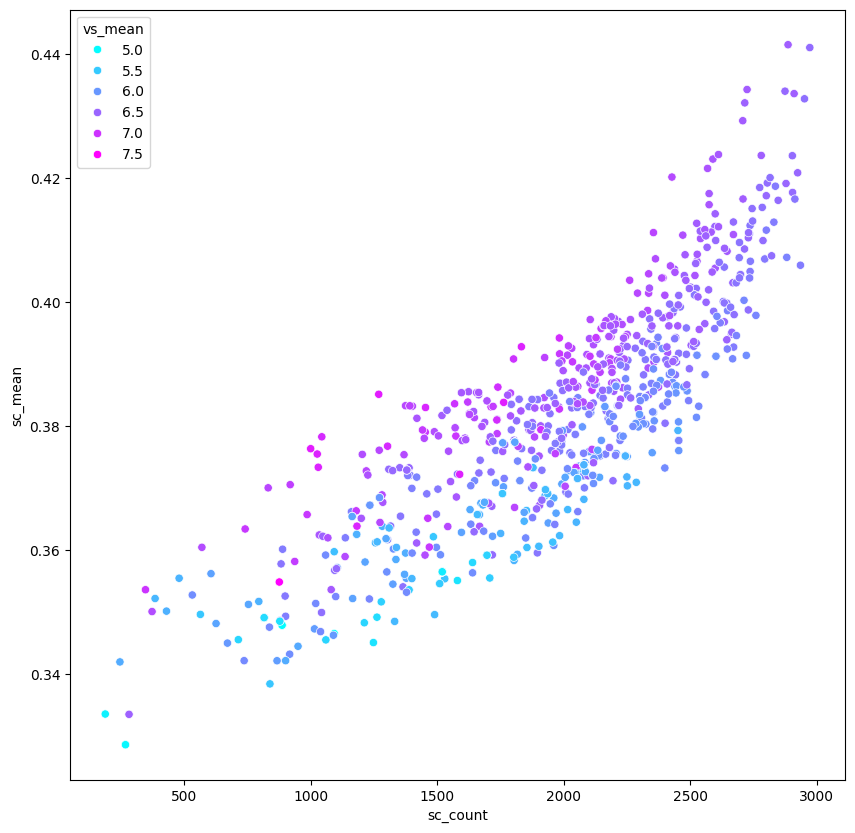

In [173]:
plt.figure(figsize=(10,10))
sns.scatterplot(df_logins, x="sc_count", y="sc_mean", palette="cool", hue = "vs_mean")

Здесь рассмотрели уже распределение относительно пользователя - а на сколько пользователи подходят под вакансии. Как можно заметить - чем выше кол-во навыков видно среди репозиториев пользователя, тем выше и его шансы подойти под большее количество вакансий. При этом, что положительно - видна коррлеяция между кол-вом вакансий, куда пользователь прошел, и средней оценкой, что, на самом деле, удивляет